In [ ]:
import psycopg2
import pandas as pd
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os

cwd = os.getcwd()  # Get the current working directory (cwd)
files = os.listdir(cwd)  # Get all the files in that directory
print("Files in %r: %s" % (cwd, files))

Files in '/content': ['.config', 'drive', 'sample_data']


In [ ]:
df = pd.read_csv("drive/My Drive/cs6601_np_anonymized.csv")
print (df["submission_html_removed"])

0       Hey guys, addressing some of the most common q...
1       Hey guys, addressing some of the most common q...
2       Hi all, \n\nI can't resubmit my implementation...
3       Hi all, \n\nI can't resubmit my implementation...
4       Hi all, \n\nI can't resubmit my implementation...
                              ...                        
7003    One improvement I think would be very helpful ...
7004    How can we get the semester grade on official ...
7005    As official as it gets, it might be the BuzzPo...
7006    I tried using the thank a teacher link.  It as...
7007    If you search for teacher, it should auto-fill...
Name: submission_html_removed, Length: 7008, dtype: object


In [ ]:
!pip install torch

In [ ]:
!pip install transformers

In [ ]:
from transformers import pipeline
model_id = "shahrukhx01/question-vs-statement-classifier"
classifier = pipeline("sentiment-analysis", model = model_id)

In [ ]:
# Example texts to analyze
texts = [
    "I love this!",
    "I hate this!",
    "How can I improve?",
    "Are you okay?",
    "I'm struggling",
    "Am I struggling?"
]

label_mapping = {
    'LABEL_0': 'Statement',
    'LABEL_1': 'Question'
}

df2 = pd.read_csv("drive/My Drive/cs6601_np_anonymized.csv")
# Apply the classifier to the submission_html_removed column of the DataFrame
df2['predictions'] = df2['submission_html_removed'].apply(lambda text: classifier(text[:512])[0])

# Replace the labels with meaningful labels -- was previously "LABEL0" and "LABEL1"
df2['predictions'] = df2['predictions'].apply(lambda prediction: {
    'label': label_mapping.get(prediction['label'], 'Unknown'),
    'score': prediction['score']
})


Ran into an issue. Tried implementing pretrained model above. Works as expected with basic data and trying to test with Piazza data. However, Piazza column data is longer than allowed limit, so everything is truncated -- this might skew results.

In [ ]:
print (df2["predictions"])

0       {'label': 'Question', 'score': 0.9850366115570...
1       {'label': 'Question', 'score': 0.9850366115570...
2       {'label': 'Question', 'score': 0.7632783651351...
3       {'label': 'Question', 'score': 0.7632783651351...
4       {'label': 'Question', 'score': 0.7483330368995...
                              ...                        
7003    {'label': 'Question', 'score': 0.9980502128601...
7004    {'label': 'Statement', 'score': 0.985631346702...
7005    {'label': 'Statement', 'score': 0.999765574932...
7006    {'label': 'Statement', 'score': 0.992701172828...
7007    {'label': 'Statement', 'score': 0.999534487724...
Name: predictions, Length: 7008, dtype: object


In [ ]:
df['predictions'] = None
for i in range(2, len(df.index)):
  df.loc[df['submission_html_removed'].str.contains("\?", na=False), 'predictions'] = "Question"
  df.loc[~df['submission_html_removed'].str.contains("\?", na=False), 'predictions'] = "Statement"


Visualizing the questions/statements in a bar graph to see the density of both

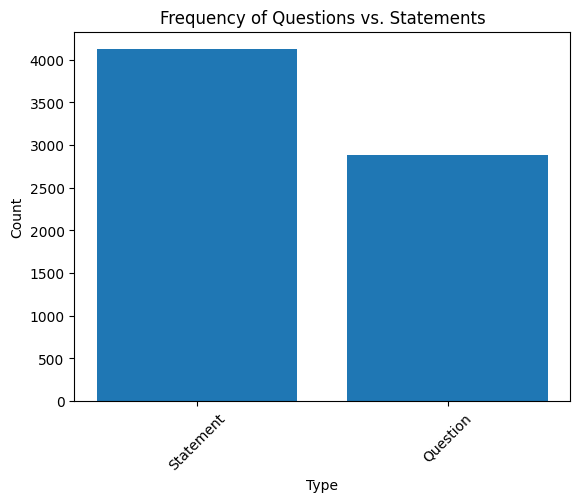

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' contains a column 'predictions' with values "Question" or "Statement"
counts = df['predictions'].value_counts()

# Plotting using matplotlib
plt.bar(counts.index, counts.values)
plt.title('Frequency of Questions vs. Statements')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Rotates labels to make them readable
plt.show()

In [ ]:
df['predictions']

0        Question
1        Question
2        Question
3        Question
4        Question
          ...    
7003    Statement
7004     Question
7005    Statement
7006     Question
7007    Statement
Name: predictions, Length: 7008, dtype: object

In [ ]:
df2['label'] = df2['predictions'].apply(lambda x: x['label'])
df2['label']

0        Question
1        Question
2        Question
3        Question
4        Question
          ...    
7003     Question
7004    Statement
7005    Statement
7006    Statement
7007    Statement
Name: label, Length: 7008, dtype: object

In [ ]:
!pip install sklearn

  Using cached sklearn-0.0.post11.tar.gz (3.6 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for sklearn: filename=sklearn-0.0.post11-py3-none-any.whl size=2959 sha256=2aa2b030ae213466a49134d9e2da5ea4604992d5e2ba7305e58d19419208e62a
  Stored in directory: /root/.cache/pip/wheels/aa/9c/60/f67813603a52fc35057868f1aba0003cc75b72583dcaa2c341
Successfully built sklearn


In [ ]:
from sklearn.metrics import accuracy_score

# Assuming df['predictions'] contains the true labels and
# df2['predictions'] contains the model's predicted labels
accuracy = accuracy_score(df['predictions'], df2['label'])

print(f"Accuracy of the model's predictions: {accuracy * 100:.2f}%")

Accuracy of the model's predictions: 70.11%


In [ ]:
df.iloc[10]['submission_html_removed']

'Double check. I got in using GATech again just fine. Try a different browser.'

In [ ]:
df.iloc[10]['predictions']